In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [6]:
df = pd.read_csv("Mall_Customers.csv")

In [7]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
df.shape

(200, 5)

In [10]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Checking for any missing values in the dataset and confirming if the data is clean.

In [11]:
missing_values = df.isnull().sum()
print("missing values per column: \n", missing_values)

missing values per column: 
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [14]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

 Ploting a scatter plot of Annual Income vs Spending Score, colored by Gender, to visually inspect initial relationships

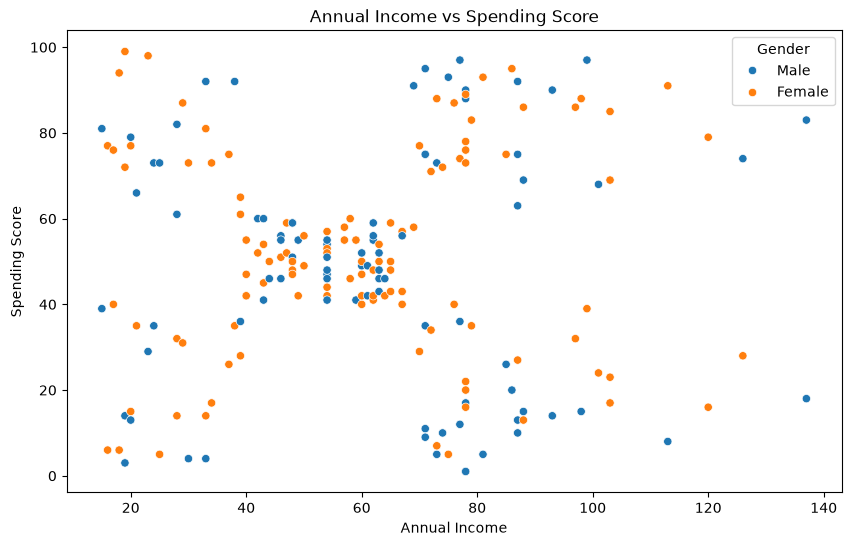

In [15]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Annual Income (k$)', y="Spending Score (1-100)", hue='Gender')
plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

K-Means Clustering
Selecting the two target features and
scaling them using StandardScaler for distance-based clustering

In [17]:
features = df[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

Runing the K-Means algorithm for k values from 1 to 10 and calculating the inertia for each to prepare for the Elbow Method.

In [22]:
inertia=[]
k_values=range(1,11)
for k in k_values:
    kmeans=KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

Plots the Elbow Curve and annotating the optimal k value.

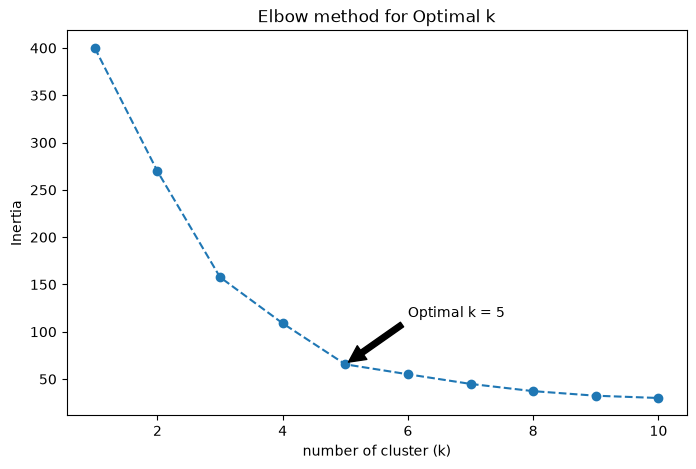

In [26]:
plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker='o', linestyle='--')
plt.title('Elbow method for Optimal k')
plt.xlabel('number of cluster (k)')
plt.ylabel('Inertia')
#marking the optimal k based on the 'elbow' point
plt.annotate('Optimal k = 5', xy=(5, inertia[4]), xytext=(6, inertia[4] +50), arrowprops=dict(facecolor='black', shrink=0.05))
plt.show()

 Fiting the K-Means model using the optimal k (k=5) and assigning the resulting cluster labels back to the original dataframe

In [33]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_features)

Ploting a scatter plot to visualize the newly formed customer segments based on their cluster assignments.

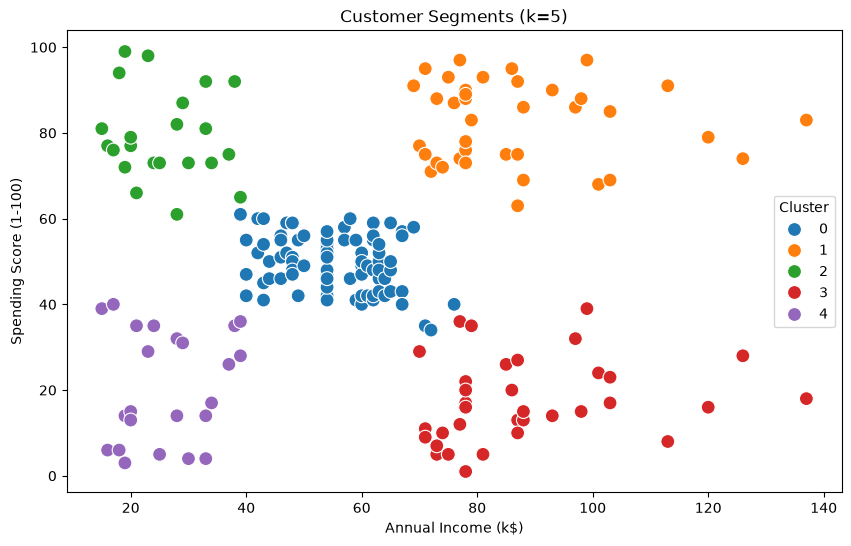

In [34]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Cluster', palette='tab10', s=100)
plt.title('Customer Segments (k=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()

Inversing the scaling to print the original coordinate values of the cluster centers

In [35]:
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

print("Cluster Centers (Annual Income, Spending Score):")
for i, center in enumerate(centers_original):
    print(f"Cluster {i}: Income = {center[0]:.2f}k$, Score = {center[1]:.2f}")

Cluster Centers (Annual Income, Spending Score):
Cluster 0: Income = 55.30k$, Score = 49.52
Cluster 1: Income = 86.54k$, Score = 82.13
Cluster 2: Income = 25.73k$, Score = 79.36
Cluster 3: Income = 88.20k$, Score = 17.11
Cluster 4: Income = 26.30k$, Score = 20.91


In [36]:
sil_score_5 = silhouette_score(scaled_features, df['Cluster'])
print(f"Silhouette Score for k=5: {sil_score_5:.4f}")

Silhouette Score for k=5: 0.5547


In [37]:
for k in [4, 6]:
    temp_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    temp_labels = temp_kmeans.fit_predict(scaled_features)
    temp_score = silhouette_score(scaled_features, temp_labels)
    print(f"Silhouette Score for k={k}: {temp_score:.4f}")

Silhouette Score for k=4: 0.4939
Silhouette Score for k=6: 0.5399


PCA Visualization

In [38]:
df_pca = df.copy()

# -------------------------------------------------------
# Step 2: Encode Gender
# Male = 0
# Female = 1
# -------------------------------------------------------
df_pca["Gender"] = df_pca["Gender"].map({
    "Male": 0,
    "Female": 1
})

# -------------------------------------------------------
# Step 3: Select Features
# -------------------------------------------------------
features = df_pca[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)",
        "Gender"
    ]
]



Applying PCA to reduce the 4-dimensional data into 2 dimensions and prints the explained variance

Explained Variance Ratio:
[0.50495142 0.49504858]

Total Variance Explained:
1.0


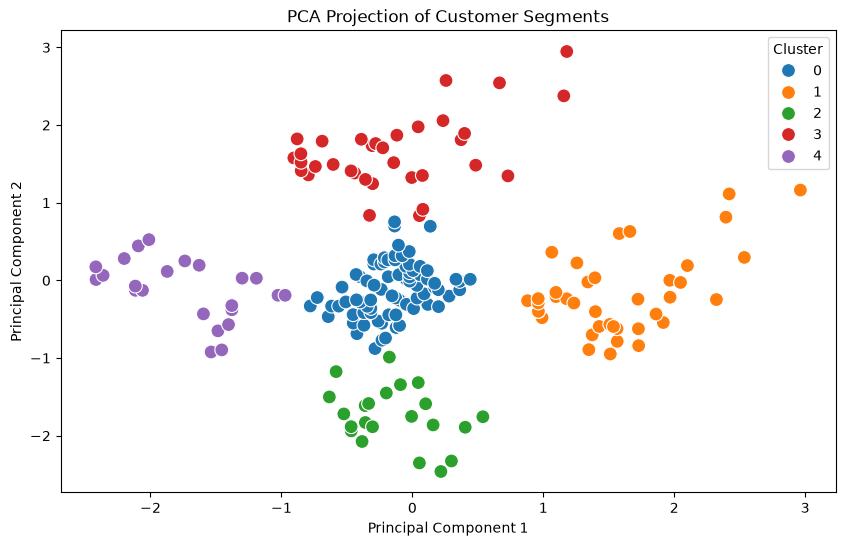

In [46]:
# -------------------------------------------------------
# Step 4: Standardize the Features
# -------------------------------------------------------
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

# -------------------------------------------------------
# Step 5: Apply PCA
# -------------------------------------------------------
pca = PCA(n_components=2)

principal_components = pca.fit_transform(scaled_features)

# -------------------------------------------------------
# Step 6: Create PCA DataFrame
# -------------------------------------------------------
pca_df = pd.DataFrame(
    principal_components,
    columns=["PC1", "PC2"]
)

# Add cluster labels
pca_df["Cluster"] = df["Cluster"]

# -------------------------------------------------------
# Step 7: Explained Variance
# -------------------------------------------------------
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print()

print("Total Variance Explained:")
print(sum(pca.explained_variance_ratio_))

# -------------------------------------------------------
# Step 8: PCA Scatter Plot
# -------------------------------------------------------
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    s=100
)

plt.title("PCA Projection of Customer Segments")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()


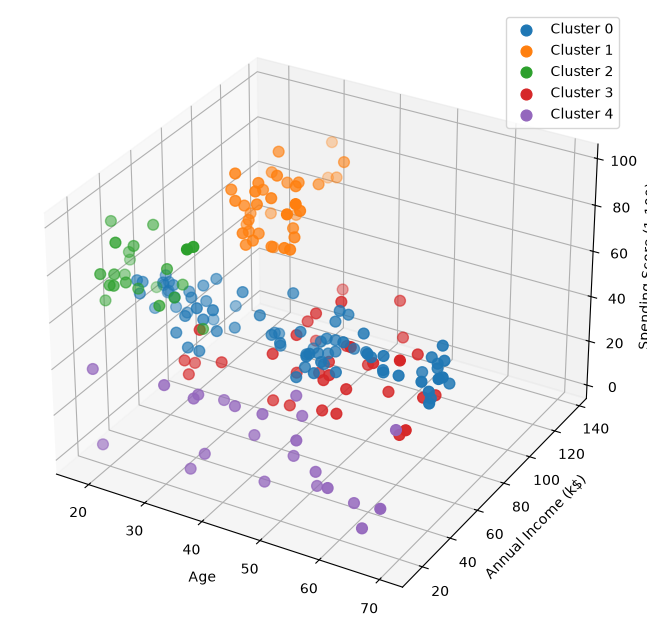

In [47]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

for cluster in sorted(df['Cluster'].unique()):
    subset = df[df['Cluster'] == cluster]

    ax.scatter(
        subset['Age'],
        subset['Annual Income (k$)'],
        subset['Spending Score (1-100)'],
        s=60,
        label=f'Cluster {cluster}'
    )

ax.set_xlabel("Age")
ax.set_ylabel("Annual Income (k$)")
ax.set_zlabel("Spending Score (1-100)")
ax.legend()
plt.show()